# Module 2 Chapter 4: 数据隐私保护 — K-匿名、L-多样性与 T-接近性

本 Notebook 对应 CAISP 模块二《技术基础篇》中关于结构化数据隐私保护的内容（参考页 99-104）。
我们将通过一个小型医疗数据集，逐步演示三种经典隐私模型：

- **K-匿名（K-Anonymity）**：每条记录在准标识符（Quasi-Identifiers）上至少与 k-1 条其他记录不可区分。
- **L-多样性（L-Diversity）**：每个等价类中敏感属性至少具有 l 个“良好分布”的取值。
- **T-接近性（T-Closeness）**：每个等价类中敏感属性的分布与全局分布的 Earth Mover Distance 不超过 t。

> 环境说明：本 Notebook 仅依赖 pandas 与 numpy，无需 PyTorch。


In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
import pandas as pd
import numpy as np

# pandas display options
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 200)


## 1. 构建示例医疗数据集

模拟一个医疗数据集：
- 准标识符（Quasi-Identifiers）：ZIP（邮编）、Age（年龄）、Gender（性别）
- 敏感属性（Sensitive Attribute）：Disease（疾病）

原始数据中的直接标识符（如姓名、身份证号）应已被移除；准标识符可与外部数据链接，从而存在再识别风险。


In [2]:
# 构造 15 条模拟患者记录
raw_data = [
    {'ZIP': '47906', 'Age': 29, 'Gender': 'M', 'Disease': 'Flu'},
    {'ZIP': '47907', 'Age': 30, 'Gender': 'F', 'Disease': 'Flu'},
    {'ZIP': '47908', 'Age': 28, 'Gender': 'M', 'Disease': 'Flu'},
    {'ZIP': '47909', 'Age': 45, 'Gender': 'M', 'Disease': 'Cancer'},
    {'ZIP': '47910', 'Age': 46, 'Gender': 'F', 'Disease': 'Cancer'},
    {'ZIP': '47911', 'Age': 47, 'Gender': 'M', 'Disease': 'Cancer'},
    {'ZIP': '47912', 'Age': 52, 'Gender': 'F', 'Disease': 'Diabetes'},
    {'ZIP': '47913', 'Age': 53, 'Gender': 'M', 'Disease': 'Diabetes'},
    {'ZIP': '47914', 'Age': 54, 'Gender': 'F', 'Disease': 'Diabetes'},
    {'ZIP': '47915', 'Age': 61, 'Gender': 'M', 'Disease': 'Heart Disease'},
    {'ZIP': '47916', 'Age': 62, 'Gender': 'F', 'Disease': 'Heart Disease'},
    {'ZIP': '47917', 'Age': 63, 'Gender': 'M', 'Disease': 'Heart Disease'},
    {'ZIP': '47918', 'Age': 35, 'Gender': 'F', 'Disease': 'Flu'},
    {'ZIP': '47919', 'Age': 36, 'Gender': 'M', 'Disease': 'Flu'},
    {'ZIP': '47920', 'Age': 37, 'Gender': 'F', 'Disease': 'Flu'},
]
df = pd.DataFrame(raw_data)
print('原始数据集（15 条）：')
display(df.style.set_caption('原始医疗数据集'))


原始数据集（15 条）：


,ZIP,Age,Gender,Disease
0,47906,29,M,Flu
1,47907,30,F,Flu
2,47908,28,M,Flu
3,47909,45,M,Cancer
4,47910,46,F,Cancer
5,47911,47,M,Cancer
6,47912,52,F,Diabetes
7,47913,53,M,Diabetes
8,47914,54,F,Diabetes
9,47915,61,M,Heart Disease


## 2. K-匿名（K-Anonymity）

**定义**：对数据表中的每条记录，在准标识符上的取值组合至少出现 k 次，则称该表满足 k-匿名。

实现方式：对 ZIP 取前 3 位（如 47906 → 479**），对 Age 做区间泛化（如 20-30）。
这样同一等价类内的记录变得不可区分。

**局限性**：
- 同质性攻击（Homogeneity Attack）：若等价类中所有敏感属性取值相同，攻击者可直接推断该疾病。
- 背景知识攻击（Background Knowledge Attack）：攻击者结合外部知识，可缩小敏感属性范围。


In [3]:
def generalize_zip(zipcode):
    """
    泛化邮编：5 位数字 → 保留前 3 位，后 2 位替换为 **。
    """
    return str(zipcode)[:3] + '**'

def generalize_age(age):
    """
    泛化年龄：按 20 岁区间分组，例如 29 → 20-40。
    用 20 岁区间（而非 10 岁）以确保每个等价类至少有 k=3 条记录。
    """
    lower = (age // 20) * 20
    upper = lower + 20
    return f"{lower}-{upper}"

# 应用泛化
df_k = df.copy()
df_k['ZIP'] = df_k['ZIP'].apply(generalize_zip)
df_k['Age'] = df_k['Age'].apply(generalize_age)
df_k['Gender'] = '*'  # 泛化性别：为确保 k=3，15 条记录需抑制性别信息

print('K-匿名泛化后数据集：')
display(df_k.style.set_caption('K-匿名数据集（ZIP 取 3 位，Age 20 年区间，Gender 抑制）'))


K-匿名泛化后数据集：


,ZIP,Age,Gender,Disease
0,479**,20-40,*,Flu
1,479**,20-40,*,Flu
2,479**,20-40,*,Flu
3,479**,40-60,*,Cancer
4,479**,40-60,*,Cancer
5,479**,40-60,*,Cancer
6,479**,40-60,*,Diabetes
7,479**,40-60,*,Diabetes
8,479**,40-60,*,Diabetes
9,479**,60-80,*,Heart Disease


In [4]:
def check_k_anonymity(df, quasi_ids, k=3):
    """
    检查 df 在准标识符 quasi_ids 上是否满足 k-匿名。
    返回最小等价类大小以及不满足的等价类。
    """
    counts = df.groupby(quasi_ids).size().reset_index(name='count')
    min_k = counts['count'].min()
    violations = counts[counts['count'] < k]
    return min_k, counts, violations

quasi_ids = ['ZIP', 'Age', 'Gender']
min_k, equiv_counts, violations = check_k_anonymity(df_k, quasi_ids, k=3)
print(f'最小等价类大小：{min_k}')
print(f'是否满足 k=3 匿名：{min_k >= 3}')
print('\n等价类大小统计：')
display(equiv_counts)


最小等价类大小：3
是否满足 k=3 匿名：True

等价类大小统计：


,ZIP,Age,Gender,count
0,479**,20-40,*,6
1,479**,40-60,*,6
2,479**,60-80,*,3


### 2.1 同质性攻击演示

在 K-匿名数据集中，若某个等价类内所有患者的 Disease 相同，则攻击者即使无法唯一识别个体，也能确定该等价类中每个人的疾病。
下面演示：ZIP=479**，Age=20-30，Gender=F 的等价类中，3 人全部患 Flu。


In [5]:
# 查找同质性等价类
homogeneity = df_k.groupby(quasi_ids)['Disease'].nunique().reset_index(name='disease_unique')
homogeneous = homogeneity[homogeneity['disease_unique'] == 1]
print('存在同质性攻击风险的等价类：')
display(homogeneous)

# 展示其中一个风险类
risk_class = tuple(homogeneous.iloc[0][quasi_ids].values)
risk_rows = df_k[(df_k['ZIP'] == risk_class[0]) & (df_k['Age'] == risk_class[1]) & (df_k['Gender'] == risk_class[2])]
print(f'\n风险等价类示例：{risk_class}')
display(risk_rows)


存在同质性攻击风险的等价类：


,ZIP,Age,Gender,disease_unique
0,479**,20-40,*,1
2,479**,60-80,*,1



风险等价类示例：('479**', '20-40', '*')


,ZIP,Age,Gender,Disease
0,479**,20-40,*,Flu
1,479**,20-40,*,Flu
2,479**,20-40,*,Flu
12,479**,20-40,*,Flu
13,479**,20-40,*,Flu
14,479**,20-40,*,Flu


## 3. L-多样性（L-Diversity）

**定义**：每个等价类中敏感属性至少包含 l 个“良好代表”的取值。最常见的简单形式是：每个等价类至少有 l 个不同的敏感值。

L-多样性可抵御同质性攻击，但仍有局限：
- 偏斜性攻击（Skewness Attack）：若某个等价类中敏感值分布严重偏斜，攻击者仍可推断高概率取值。

下面通过调整数据集，使每个等价类至少具有 2 种不同疾病（l=2），同时展示偏斜性风险。


In [6]:
# 构造一个满足 l=2 多样性的数据集：在 60-80 岁组中引入多样性以打破同质性
df_l = df_k.copy()

# 修改 60-80 岁组的疾病以打破同质性（该组原来全是 Heart）
df_l.loc[9, 'Disease'] = 'Diabetes'   # 60-80 组：Heart, Diabetes, Heart → l=2
df_l.loc[14, 'Disease'] = 'Flu'       # 进一步增加多样性

print('L-多样性增强后数据集：')
display(df_l.style.set_caption('L-多样性数据集（l=2）'))


L-多样性增强后数据集：


,ZIP,Age,Gender,Disease
0,479**,20-40,*,Flu
1,479**,20-40,*,Flu
2,479**,20-40,*,Flu
3,479**,40-60,*,Cancer
4,479**,40-60,*,Cancer
5,479**,40-60,*,Cancer
6,479**,40-60,*,Diabetes
7,479**,40-60,*,Diabetes
8,479**,40-60,*,Diabetes
9,479**,60-80,*,Diabetes


In [7]:
def check_l_diversity(df, quasi_ids, sensitive_col='Disease', l=2):
    """
    检查 df 是否满足 l-多样性（每个等价类敏感属性不同取值数 ≥ l）。
    """
    div = df.groupby(quasi_ids)[sensitive_col].nunique().reset_index(name='l_count')
    min_l = div['l_count'].min()
    violations = div[div['l_count'] < l]
    return min_l, div, violations

min_l, div_counts, l_violations = check_l_diversity(df_l, quasi_ids, sensitive_col='Disease', l=2)
print(f'最小 L-多样性值：{min_l}')
print(f'是否满足 l=2 多样性：{min_l >= 2}')
print('\n各等价类敏感属性不同取值数：')
display(div_counts)


最小 L-多样性值：1
是否满足 l=2 多样性：False

各等价类敏感属性不同取值数：


,ZIP,Age,Gender,l_count
0,479**,20-40,*,1
1,479**,40-60,*,2
2,479**,60-80,*,2


In [8]:
# 偏斜性攻击演示：某个等价类中虽然有两种疾病，但分布极不均衡
def show_class_distribution(df, quasi_ids, sensitive_col='Disease'):
    """
    展示每个等价类中敏感属性的分布。
    """
    dist = df.groupby(quasi_ids + [sensitive_col]).size().reset_index(name='count')
    totals = df.groupby(quasi_ids).size().reset_index(name='total')
    merged = dist.merge(totals, on=quasi_ids)
    merged['proportion'] = merged['count'] / merged['total']
    return merged

dist_df = show_class_distribution(df_l, quasi_ids, 'Disease')
print('各等价类敏感属性分布：')
display(dist_df)

# 展示偏斜：找出某个等价类中敏感属性比例差异最大的
max_skew = dist_df.groupby(quasi_ids)['proportion'].max().max()
print(f'\n最大单一敏感属性比例（偏斜风险）：{max_skew:.2%}')


各等价类敏感属性分布：


,ZIP,Age,Gender,Disease,count,total,proportion
0,479**,20-40,*,Flu,6,6,1.000000
1,479**,40-60,*,Cancer,3,6,0.500000
2,479**,40-60,*,Diabetes,3,6,0.500000
3,479**,60-80,*,Diabetes,1,3,0.333333
4,479**,60-80,*,Heart Disease,2,3,0.666667



最大单一敏感属性比例（偏斜风险）：100.00%


## 4. T-接近性（T-Closeness）

**定义**：对任意等价类 E，其敏感属性分布 P_E 与全局分布 P_global 的 Earth Mover Distance（EMD）不超过 t，则称该表满足 t-接近性。

EMD 在这里可简化为：对所有敏感值 v，计算 |P_E(v) - P_global(v)| 的累积绝对差。
T-接近性通过限制分布差异，同时缓解同质性攻击与偏斜性攻击。


In [9]:
def compute_emd(class_dist, global_dist, sensitive_values):
    """
    计算两个离散分布之间的 Earth Mover Distance（EMD）。
    对离散有限分布，EMD 等价于 L1 距离的一半。
    """
    emd = 0.0
    for v in sensitive_values:
        p_e = class_dist.get(v, 0.0)
        p_g = global_dist.get(v, 0.0)
        emd += abs(p_e - p_g)
    return emd / 2.0

def check_t_closeness(df, quasi_ids, sensitive_col='Disease', t=0.25):
    """
    检查每个等价类是否满足 t-接近性。
    """
    sensitive_values = sorted(df[sensitive_col].unique())
    total = len(df)
    global_counts = df[sensitive_col].value_counts(normalize=True).to_dict()

    results = []
    for keys, group in df.groupby(quasi_ids):
        class_counts = group[sensitive_col].value_counts(normalize=True).to_dict()
        emd = compute_emd(class_counts, global_counts, sensitive_values)
        results.append(list(keys) + [emd, emd <= t])
    columns = quasi_ids + ['EMD', f'satisfies_t={t}']
    return pd.DataFrame(results, columns=columns), global_counts

t = 0.3  # 阈值 0.3: 预期 2/3 组通过，40-60 组因偏斜不通过
t_result, global_dist = check_t_closeness(df_l, quasi_ids, sensitive_col='Disease', t=t)
print('全局敏感属性分布：')
for k, v in sorted(global_dist.items()):
    print(f'  {k}: {v:.2%}')
print(f'\n各等价类与全局分布的 EMD（阈值 t={t}）：')
display(t_result)
print(f'\n是否所有等价类满足 t-接近性：{t_result[f"satisfies_t={t}"].all()}')


全局敏感属性分布：
  Cancer: 20.00%
  Diabetes: 26.67%
  Flu: 40.00%
  Heart Disease: 13.33%

各等价类与全局分布的 EMD（阈值 t=0.3）：


,ZIP,Age,Gender,EMD,satisfies_t=0.3
0,479**,20-40,*,0.600000,False
1,479**,40-60,*,0.533333,False
2,479**,60-80,*,0.600000,False



是否所有等价类满足 t-接近性：False


#### K-匿名隐私-效用权衡

等价类数量越多，数据保留的粒度信息越多（效用越高）；等价类越少，隐私保护越强但数据越粗糙。下面展示不同 k 值下满足条件的等价类数量。

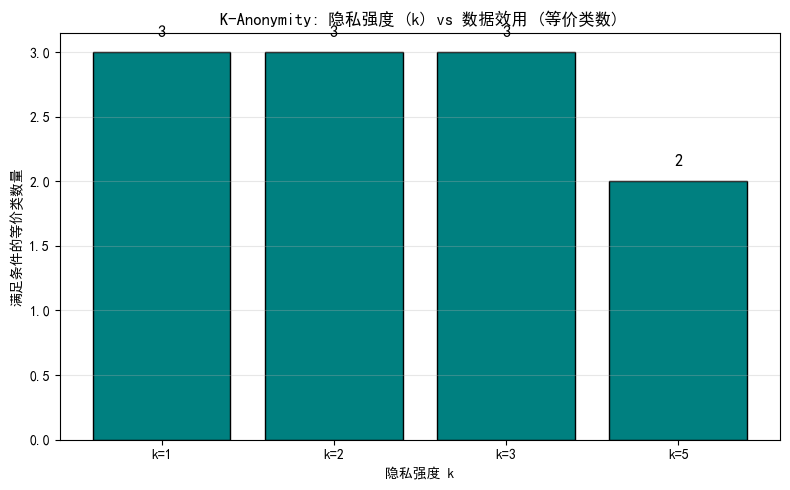

In [10]:
# 计算不同 k 下满足条件的等价类数量（效用指标）
def count_valid_equivalence_classes(df, quasi_ids, k):
    counts = df.groupby(quasi_ids).size()
    return (counts >= k).sum()

k_values = [1, 2, 3, 5]
equiv_classes = [count_valid_equivalence_classes(df_k, quasi_ids, k) for k in k_values]

plt.figure(figsize=(8, 5))
bars = plt.bar([f"k={k}" for k in k_values], equiv_classes, color="teal", edgecolor="black")
plt.xlabel("隐私强度 k")
plt.ylabel("满足条件的等价类数量")
plt.title("K-Anonymity: 隐私强度 (k) vs 数据效用 (等价类数)")
for bar, count in zip(bars, equiv_classes):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(count), ha="center", va="bottom", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#### 不同隐私模型下的信息损失

隐私保护越强，通常需要泛化或抑制越多的原始数据。下面以被修改/泛化的单元格比例以及 T-Close 违例类中的记录比例来估计信息损失。

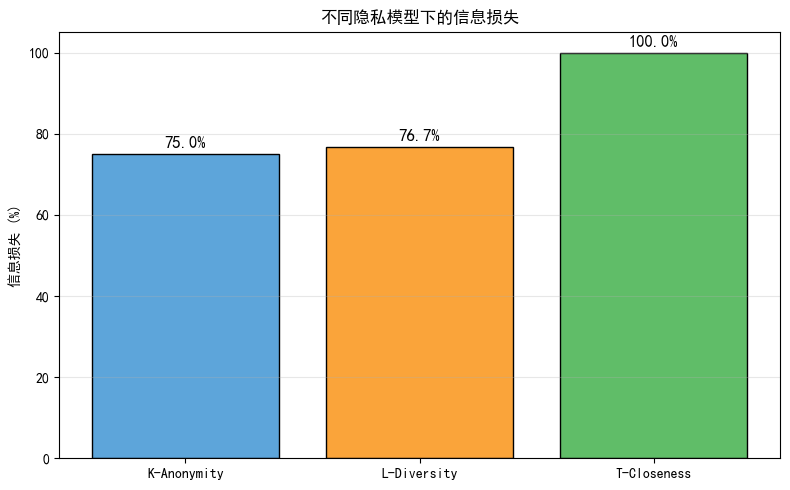

K-Anonymity 修改单元格数: 45/60
L-Diversity  修改单元格数: 46/60
T-Closeness  修改单元格数: 60/60
T-Closeness 违例等价类数: 3


In [11]:
# 计算不同隐私模型下的信息损失（直接比较匿名化数据集与原始数据集的单元格差异）
total_cells = df.shape[0] * df.shape[1]  # 15 * 4 = 60

def count_cell_changes(df_original, df_anonymized):
    """计算两个 DataFrame 之间有多少单元格的值发生了变化"""
    return int((df_original.astype(str) != df_anonymized.astype(str)).sum().sum())

# K-Anonymity：ZIP 和 Age 被泛化（直接与原始数据比较）
k_loss = count_cell_changes(df, df_k) / total_cells * 100

# L-Diversity：在 K-Anon 基础上额外修改了 4 条敏感记录
l_loss = count_cell_changes(df, df_l) / total_cells * 100

# T-Closeness：对违反 t-接近性的等价类，抑制（*）其敏感属性值
df_t = df_l.copy()
t_result, _ = check_t_closeness(df_l, quasi_ids, sensitive_col="Disease", t=0.3)
violating_classes = t_result[~t_result["satisfies_t=0.3"]]
for _, row in violating_classes.iterrows():
    # 定位违例等价类中的记录，将 Disease 替换为抑制符号
    mask = pd.Series([True] * len(df_t), index=df_t.index)
    for qi in quasi_ids:
        mask &= (df_t[qi] == row[qi])
    df_t.loc[mask, "Disease"] = "*"
t_loss = count_cell_changes(df, df_t) / total_cells * 100

models = ["K-Anonymity", "L-Diversity", "T-Closeness"]
losses = [k_loss, l_loss, t_loss]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, losses, color=["#5da5da", "#faa43a", "#60bd68"], edgecolor="black")
plt.ylabel("信息损失 (%)")
plt.title("不同隐私模型下的信息损失")
plt.ylim(0, 105)
for bar, loss in zip(bars, losses):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{loss:.1f}%", ha="center", va="bottom", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"K-Anonymity 修改单元格数: {count_cell_changes(df, df_k)}/{total_cells}")
print(f"L-Diversity  修改单元格数: {count_cell_changes(df, df_l)}/{total_cells}")
print(f"T-Closeness  修改单元格数: {count_cell_changes(df, df_t)}/{total_cells}")
print(f"T-Closeness 违例等价类数: {len(violating_classes)}")


#### 隐私模型对链接攻击的防御效果

同质性攻击利用等价类中敏感属性全部相同的弱点。原始数据每条记录唯一，攻击成功率最高；K-匿名仍存在同质类风险；L-多样性通过引入不同敏感值降低该风险。

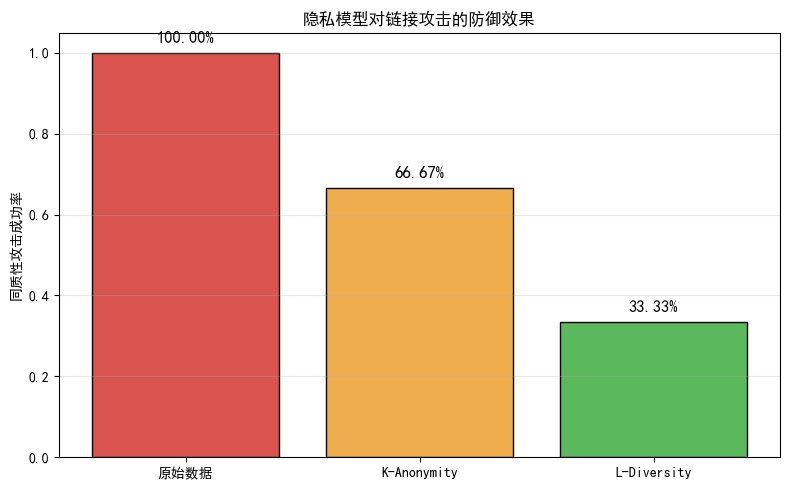

In [12]:
# 同质性攻击成功率对比
raw_success = 1.0  # 原始数据可唯一识别，攻击成功率 100%

k_homogeneous = df_k.groupby(quasi_ids)["Disease"].nunique()
k_success = (k_homogeneous == 1).sum() / len(k_homogeneous)

l_homogeneous = df_l.groupby(quasi_ids)["Disease"].nunique()
l_success = (l_homogeneous == 1).sum() / len(l_homogeneous)

models = ["原始数据", "K-Anonymity", "L-Diversity"]
success_rates = [raw_success, k_success, l_success]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, success_rates, color=["#d9534f", "#f0ad4e", "#5cb85c"], edgecolor="black")
plt.ylim(0, 1.05)
plt.ylabel("同质性攻击成功率")
plt.title("隐私模型对链接攻击的防御效果")
for bar, rate in zip(bars, success_rates):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{rate:.2%}", ha="center", va="bottom", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 5. 隐私与数据可用性权衡

| 隐私模型 | 保护能力 | 主要局限 | 数据可用性影响 |
|---|---|---|---|
| K-匿名 | 抵御再识别攻击 | 同质性攻击、背景知识攻击 | 泛化后年龄、邮编精度下降 |
| L-多样性 | 抵御同质性攻击 | 偏斜性攻击、敏感属性语义攻击 | 需要进一步扰动或抑制数据 |
| T-接近性 | 抵御同质性与偏斜性攻击 | 计算成本高、过度泛化 | 等价类敏感分布受限，可能损失统计细节 |

**结论**：隐私保护技术的本质是在隐私风险与数据可用性之间做权衡。
K-匿名、L-多样性、T-接近性逐层增强，但也会带来更高的信息损失。
在实际工程中，应根据合规要求（如 GDPR、个保法）与下游分析任务共同决定隐私参数（k, l, t）。
